In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Set visualization aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load the dataset
# Update the path if running locally vs on Kaggle
df = pd.read_csv('user_behavior_dataset.csv')

print("📊 Dataset Sample:")
print(df.head())

# Quick check for missing values
print("\nMissing Values:")
print(df[['Screen On Time (hours/day)', 'Battery Drain (mAh/day)']].isnull().sum())

📊 Dataset Sample:
   User ID    Device Model Operating System  App Usage Time (min/day)  \
0        1  Google Pixel 5          Android                       393   
1        2       OnePlus 9          Android                       268   
2        3    Xiaomi Mi 11          Android                       154   
3        4  Google Pixel 5          Android                       239   
4        5       iPhone 12              iOS                       187   

   Screen On Time (hours/day)  Battery Drain (mAh/day)  \
0                         6.4                     1872   
1                         4.7                     1331   
2                         4.0                      761   
3                         4.8                     1676   
4                         4.3                     1367   

   Number of Apps Installed  Data Usage (MB/day)  Age  Gender  \
0                        67                 1122   40    Male   
1                        42                  944   47  Female   

In [3]:
# Define Feature (X) and Target (y)
X = df[['Screen On Time (hours/day)']].values  # 2D array for features
y = df['Battery Drain (mAh/day)'].values       # 1D array for target

# Split into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]} rows")
print(f"Testing data size: {X_test.shape[0]} rows")

Training data size: 560 rows
Testing data size: 140 rows


In [4]:
# Initialize the model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("✅ Linear Regression model trained successfully.")
print(f"Base Drain (Intercept): {model.intercept_:.2f} mAh")
print(f"Drain per Hour (Slope): {model.coef_[0]:.2f} mAh/hour")

✅ Linear Regression model trained successfully.
Base Drain (Intercept): 184.14 mAh
Drain per Hour (Slope): 254.45 mAh/hour


C:\Users\BENJITH BABU\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128267 (\N{BATTERY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


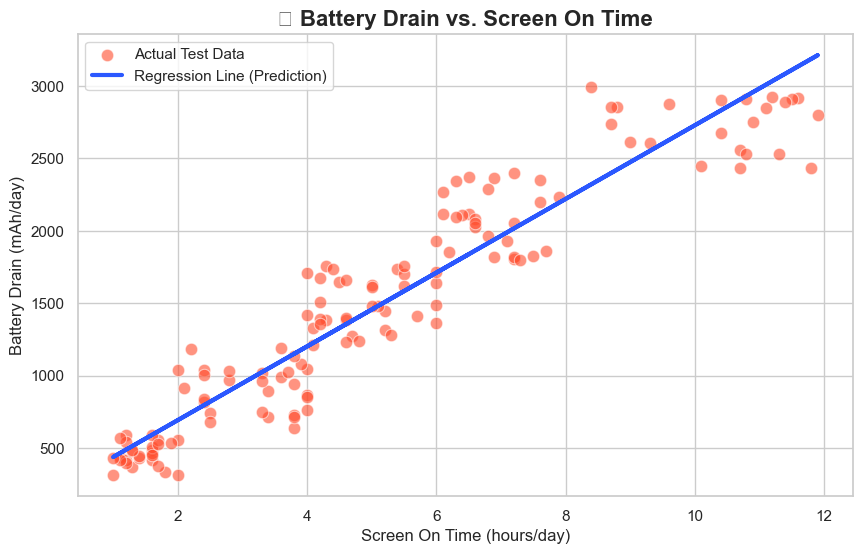

In [5]:
# Make predictions on the test set for visualization
y_pred = model.predict(X_test)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot actual data points from the test set
sns.scatterplot(x=X_test.flatten(), y=y_test, color='#ff4b2b', s=80, alpha=0.6, label='Actual Test Data')

# Plot the regression line
plt.plot(X_test, y_pred, color='#2b58ff', linewidth=3, label='Regression Line (Prediction)')

plt.title('🔋 Battery Drain vs. Screen On Time', fontsize=16, fontweight='bold')
plt.xlabel('Screen On Time (hours/day)', fontsize=12)
plt.ylabel('Battery Drain (mAh/day)', fontsize=12)
plt.legend()
plt.show()

In [6]:
# Model Evaluation
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"📊 Overall R² Score: {r2:.4f} (1.0 is perfect)")
print(f"📊 Mean Squared Error: {mse:.2f}")

# Custom Prediction Function
def predict_battery_drain(hours):
    prediction = model.predict([[hours]])[0]
    print(f"\n🔮 Prediction for {hours} hours of Screen On Time:")
    print(f"Estimated Battery Drain: {prediction:.0f} mAh/day")

# Try it yourself!
try:
    user_input = float(input("Enter Screen On Time in hours (e.g., 5.5): "))
    predict_battery_drain(user_input)
except ValueError:
    print("❌ Invalid input! Please enter a number.")

📊 Overall R² Score: 0.8924 (1.0 is perfect)
📊 Mean Squared Error: 66751.94

🔮 Prediction for 5.0 hours of Screen On Time:
Estimated Battery Drain: 1456 mAh/day
